# Phần 6: Đánh giá mô hình Hồi quy (Regression Evaluation)

> **Mục tiêu:** Thực hiện đánh giá toàn diện các mô hình hồi quy đã được huấn luyện tại các giai đoạn trước (Linear Regression, Regularized Regression, Nonlinear Models). Việc đánh giá không chỉ dừng lại ở các chỉ số lỗi trên tập kiểm tra mà còn sử dụng phương pháp thống kê để xác định mô hình có thực sự ưu việt hay không.

**Nội dung cốt lõi:**
- **Tính toán các chỉ số đánh giá (Evaluation Metrics):** $	ext{MSE}$, $	ext{RMSE}$, $	ext{MAE}$, $R^2$, $	ext{MedAE}$ và Adjusted $R^2$.
- **Trực quan hóa (Visualizations):** Đường cong học tập (Learning Curves), phân tích phần dư (Residual Plots), đồ thị Dự đoán thực tế (Predicted vs Actual) và biểu đồ QQ-Plot.
- **Kiểm định chéo (Cross-Validation):** Đánh giá mức độ ổn định của các mô hình thông qua **10-Fold CV**.
- **Kiểm định thống kê (Statistical Significance Tests):** Áp dụng **Friedman Test** và **Wilcoxon Signed-Rank Test** để kiểm chứng sự khác biệt có ý nghĩa thống kê.
- **Bảng tổng hợp đánh giá:** Cung cấp bức tranh toàn cảnh để ra quyết định chọn mô hình tốt nhất.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")


def _resolve_module_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / "models" / "linear_regression.py").exists() and (candidate / "evaluation" / "metrics.py").exists():
            return candidate
        if (candidate / "code" / "Part1_Regression" / "models" / "linear_regression.py").exists():
            return candidate / "code" / "Part1_Regression"
    raise FileNotFoundError("Could not locate code/Part1_Regression module root.")


def _resolve_results_dir(module_root: Path) -> Path:
    candidates = [
        module_root / "models" / "results",
        module_root / "results",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    candidates[0].mkdir(parents=True, exist_ok=True)
    return candidates[0].resolve()


PROJECT_ROOT = _resolve_module_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Reproducibility ---
from utils import set_seed
set_seed(42)

# --- Data loading ---
from eda_preprocessing.load_data import load_regression_data

# --- Models (chi import de dung cho learning curves va CV, KHONG train lai) ---
from models.linear_regression import (
    NormalEquationLR, MiniBatchGDLR, WeightedLeastSquares,
)
from models.regularized_regression import (
    RidgeRegression, LassoRegression, ElasticNetRegression,
)
from models.nonlinear_models import (
    PolynomialRegression, RBFRegression, FourierBasisRegression,
)
from models.bonus_models import (
    KernelRidgeRegression, RobustRegression,
)

# --- Evaluation ---
from evaluation.metrics import (
    compute_all_metrics, print_metrics,
    cross_validate_model, print_cv_results,
    verify_against_sklearn, k_fold_split,
)
from evaluation.plots import (
    plot_learning_curves, plot_residuals, plot_predicted_vs_actual,
    plot_qq, plot_model_comparison, plot_convergence,
    plot_cv_boxplot, plot_multi_residuals,
)
from evaluation.statistical_tests import (
    paired_t_test, wilcoxon_test, compare_models,
)

# --- Results directory ---
RESULTS_DIR = _resolve_results_dir(PROJECT_ROOT)

print("All imports loaded successfully.")
print(f"Module root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Files found: {[p.name for p in RESULTS_DIR.glob('*.joblib')]}")




All imports loaded successfully.
Module root: D:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\code\Part1_Regression
Results directory: D:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\code\Part1_Regression\models\results
Files found: ['best_params_04.joblib', 'best_params_05.joblib', 'metrics_03_linear_regression.joblib', 'metrics_04_regularized_regression.joblib', 'metrics_05_nonlinear_models.joblib', 'predictions_03_linear_regression.joblib', 'predictions_04_regularized_regression.joblib', 'predictions_05_nonlinear_models.joblib', 'trained_models_03.joblib', 'trained_models_04.joblib', 'trained_models_05.joblib']


In [2]:
data = load_regression_data(use_log_target=True)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]
feature_names = data["feature_names"]
weights_train = data["weights_train"]
weights_val = data["weights_val"]
weights_test = data["weights_test"]
weights_cv = np.concatenate([weights_train, weights_val])

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Features: {feature_names}")
print(f"weights_cv: {weights_cv.shape}")



Train: (12165, 49), Val: (1737, 49), Test: (3477, 49)
Features: ['temp', 'hum', 'windspeed', 'season_2', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'time_of_day_1', 'time_of_day_2', 'yr', 'workingday', 'holiday', 'is_rush_hour']
weights_cv: (13902,)


## 6.1. Chi tiết các chỉ số đánh giá (Evaluation Metrics)

Để đánh giá chất lượng mô hình hồi quy một cách đa chiều, chúng ta sử dụng các chỉ số sau đây (tất cả đều được implement từ đầu mà không sử dụng `sklearn`):

- **MSE (Mean Squared Error)**: Trừng phạt mạnh những điểm dữ liệu dự đoán sai lệch lớn (outliers) bằng cách bình phương sai số.
  $$	ext{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$$

- **RMSE (Root Mean Squared Error)**: Có cùng đơn vị với biến mục tiêu ($y$), giúp chúng ta dễ dàng diễn giải độ lớn của sai số so với trung bình của tập dữ liệu.
  $$	ext{RMSE} = \sqrt{	ext{MSE}}$$

- **MAE (Mean Absolute Error)**: Sai số tuyệt đối trung bình, đánh giá theo tỷ lệ tuyến tính với các sai số nên ít bị ảnh hưởng bởi điểm ngoại lai hơn so với $	ext{MSE}$.
  $$	ext{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$$

- **$R^2$ (Coefficient of Determination)**: Tỷ lệ phương sai của biến mục tiêu được giải thích bởi mô hình. Giá trị lý tưởng là $1.0$, trong khi giá trị $0.0$ tương đương với việc mô hình chỉ đoán được giá trị trung bình. Dưới $0.0$ nghĩa là mô hình còn tệ hơn cả giá trị trung bình.
  $$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2} = 1 - \frac{	ext{SS}_{	ext{res}}}{	ext{SS}_{	ext{tot}}}$$

- **MedAE (Median Absolute Error)**: Chỉ số đặc biệt **kháng lại các điểm ngoại lai** (robust to outliers). Bằng cách lấy trung vị thay vì trung bình, chỉ số này loại bỏ sự ảnh hưởng dội ngược từ các sample bất thường.
  $$	ext{MedAE} = 	ext{median}(|y_1-\hat{y}_1|, \ldots, |y_n-\hat{y}_n|)$$

## 6.2. Nạp kết quả đã huấn luyện từ Phase 2

Để tiết kiệm thời gian tính toán và đảm bảo tính thống nhất, notebook này **KHÔNG** thực hiện quá trình huấn luyện (training) lại toàn bộ từ đầu.
Bằng việc nạp các trạng thái mô hình từ đĩa, chúng ta tận dụng tối đa tài nguyên hiện có. Cụ thể:

- **Notebook 03 (Linear):** OLS, Mini-batch GD, Weighted Least Squares.
- **Notebook 04 (Regularized):** Ridge, Lasso, Elastic Net.
- **Notebook 05 (Nonlinear):** Polynomial regression, RBF network, Fourier basis.

Mỗi mô hình được lưu lại dưới dạng **Joblib** components bao gồm:
1. `predictions_<NB>.joblib`: Chứa vector $\hat{y}$ trên tập Validation và Test.
2. `trained_models_<NB>.joblib`: Tham chiếu bộ mô hình đã được fitting để chạy Cross-Validation.
3. `metrics_<NB>.joblib`: Kết quả metrics đã trích xuất sẵn.
4. `best_params_<NB>.joblib`: Siêu tham số (Hyperparameter) tốt nhất được tìm ra trong Grid Search.

In [3]:
# ============================================================
# LOAD SAVED RESULTS FROM PHASE 2 NOTEBOOKS
# ============================================================
# Each teammate saves their results to results/ directory.
# This cell loads all available results and falls back to
# re-training if a file is missing.
# ============================================================

all_predictions = {}
trained_models = {}

# --- Define which files to load ---
SAVED_FILES = {
    "predictions": [
        "predictions_03_linear_regression.joblib",
        "predictions_04_regularized_regression.joblib",
        "predictions_05_nonlinear_models.joblib",
    ],
    "models": [
        "trained_models_03.joblib",
        "trained_models_04.joblib",
        "trained_models_05.joblib",
    ],
}

# --- Load predictions ---
for fname in SAVED_FILES["predictions"]:
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        preds = joblib.load(fpath)
        all_predictions.update(preds)
        print(f"Loaded predictions from {fname}: {list(preds.keys())}")
    else:
        print(f"WARNING: {fname} not found. Models from this file will be retrained.")

# --- Load trained models ---
for fname in SAVED_FILES["models"]:
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        models = joblib.load(fpath)
        trained_models.update(models)
        print(f"Loaded models from {fname}: {list(models.keys())}")
    else:
        print(f"WARNING: {fname} not found.")

print(f"\nTotal predictions loaded: {len(all_predictions)}")
print(f"Total models loaded: {len(trained_models)}")
print(f"Models: {list(all_predictions.keys())}")

Loaded predictions from predictions_03_linear_regression.joblib: ['OLS (Normal Eq.)', 'Mini-batch GD', 'WLS']
Loaded predictions from predictions_04_regularized_regression.joblib: ['Ridge', 'Lasso', 'ElasticNet']
Loaded predictions from predictions_05_nonlinear_models.joblib: ['Polynomial', 'RBF', 'Fourier']
Loaded models from trained_models_03.joblib: ['OLS (Normal Eq.)', 'Mini-batch GD', 'WLS']
Loaded models from trained_models_04.joblib: ['Ridge', 'Lasso', 'ElasticNet']
Loaded models from trained_models_05.joblib: ['Polynomial', 'RBF', 'Fourier']

Total predictions loaded: 9
Total models loaded: 9
Models: ['OLS (Normal Eq.)', 'Mini-batch GD', 'WLS', 'Ridge', 'Lasso', 'ElasticNet', 'Polynomial', 'RBF', 'Fourier']


In [4]:
# ============================================================
# BUILD MODEL REGISTRY FOR CV / STATISTICAL TESTS
# ============================================================
# Reconstruct the model definitions directly from the saved
# trained model objects so CV names stay aligned with Phase 2 exports.
# ============================================================


def _add_bias_eval(X):
    return np.column_stack([np.ones(X.shape[0]), X])


class StableNormalEquationLR(NormalEquationLR):
    """Numerically-stable OLS used for evaluation utilities."""

    def fit(self, X, y, **kwargs):
        X_b = _add_bias_eval(X)
        XtX = X_b.T @ X_b + 1e-8 * np.eye(X_b.shape[1])
        Xty = X_b.T @ y
        self.w = np.linalg.solve(XtX, Xty)
        self.fit_time = 0.0
        return self


class StableWeightedLeastSquares(WeightedLeastSquares):
    """Numerically-stable WLS used for evaluation utilities."""

    def fit(self, X, y, weights=None, **kwargs):
        X_b = _add_bias_eval(X)
        if weights is None:
            weights = np.ones(len(y))
        sqrt_w = np.sqrt(weights)
        X_w = X_b * sqrt_w[:, np.newaxis]
        y_w = y * sqrt_w
        XtX = X_w.T @ X_w + 1e-8 * np.eye(X_w.shape[1])
        Xty = X_w.T @ y_w
        self.w = np.linalg.solve(XtX, Xty)
        self.fit_time = 0.0
        return self


def _require_trained_model(name: str):
    if name not in trained_models:
        raise KeyError(f"Missing trained model: {name}. Re-run the export cell in the source notebook.")
    return trained_models[name]


ols_model = _require_trained_model("OLS (Normal Eq.)")
gd_model = _require_trained_model("Mini-batch GD")
wls_model = _require_trained_model("WLS")
ridge_model = _require_trained_model("Ridge")
lasso_model = _require_trained_model("Lasso")
enet_model = _require_trained_model("ElasticNet")
poly_model = _require_trained_model("Polynomial")
rbf_model = _require_trained_model("RBF")
fourier_model = _require_trained_model("Fourier")

MODEL_REGISTRY = {
    "OLS (Normal Eq.)": {
        "class": StableNormalEquationLR,
        "kwargs": {},
        "fit_kwargs": {},
    },
    "Mini-batch GD": {
        "class": MiniBatchGDLR,
        "kwargs": {
            "lr": float(gd_model.lr_init),
            "n_epochs": int(gd_model.n_epochs),
            "batch_size": int(gd_model.batch_size),
            "lr_schedule": gd_model.lr_schedule,
            "decay_rate": float(gd_model.decay_rate),
            "decay_steps": int(gd_model.decay_steps),
            "lr_min": float(gd_model.lr_min),
            "verbose": bool(gd_model.verbose),
        },
        "fit_kwargs": {"seed": 42},
    },
    "WLS": {
        "class": StableWeightedLeastSquares,
        "kwargs": {},
        "fit_kwargs": {"weights": weights_train},
    },
    "Ridge": {
        "class": RidgeRegression,
        "kwargs": {"lam": float(ridge_model.lam)},
        "fit_kwargs": {},
    },
    "Lasso": {
        "class": LassoRegression,
        "kwargs": {
            "lam": float(lasso_model.lam),
            "max_iter": int(lasso_model.max_iter),
            "tol": float(lasso_model.tol),
        },
        "fit_kwargs": {},
    },
    "ElasticNet": {
        "class": ElasticNetRegression,
        "kwargs": {
            "lam1": float(enet_model.lam1),
            "lam2": float(enet_model.lam2),
            "max_iter": int(enet_model.max_iter),
            "tol": float(enet_model.tol),
        },
        "fit_kwargs": {},
    },
    "Polynomial": {
        "class": PolynomialRegression,
        "kwargs": {
            "degree": int(poly_model.degree),
            "include_interactions": bool(poly_model.include_interactions),
        },
        "fit_kwargs": {},
    },
    "RBF": {
        "class": RBFRegression,
        "kwargs": {
            "n_centers": int(rbf_model.n_centers),
            "sigma": float(rbf_model.sigma),
            "center_method": rbf_model.center_method,
        },
        "fit_kwargs": {"seed": 42},
    },
    "Fourier": {
        "class": FourierBasisRegression,
        "kwargs": {
            "n_harmonics": int(fourier_model.n_harmonics),
            "feature_indices": fourier_model.feature_indices,
        },
        "fit_kwargs": {},
    },
}

print("MODEL_REGISTRY built successfully.")
print(list(MODEL_REGISTRY.keys()))



MODEL_REGISTRY built successfully.
['OLS (Normal Eq.)', 'Mini-batch GD', 'WLS', 'Ridge', 'Lasso', 'ElasticNet', 'Polynomial', 'RBF', 'Fourier']


## 6.3. Bảng tổng hợp chỉ số đánh giá Validation & Test

Bảng dưới đây cung cấp thông số dự đoán chi tiết cho cả 2 bộ dữ liệu:
- **Tập Validation:** Được sử dụng làm kim chỉ nam để lựa chọn siêu tham số tối ưu (Hyperparameter tuning) ở các phase trước.
- **Tập Test:** Bộ dữ liệu chưa từng được mô hình nhìn thấy, đóng vai trò chứng minh tính tổng quát hóa (generalization) của mô hình.

In [5]:
# Compute metrics for all models on validation and test sets.
results_rows = []

for name, preds in all_predictions.items():
    val_m = compute_all_metrics(y_val, preds["y_pred_val"])
    test_m = compute_all_metrics(y_test, preds["y_pred_test"])

    results_rows.append({
        "Model": name,
        "Val_MSE": val_m["MSE"],
        "Val_RMSE": val_m["RMSE"],
        "Val_MAE": val_m["MAE"],
        "Val_R2": val_m["R\u00b2"],
        "Test_MSE": test_m["MSE"],
        "Test_RMSE": test_m["RMSE"],
        "Test_MAE": test_m["MAE"],
        "Test_R2": test_m["R\u00b2"],
    })

    print_metrics(val_m, model_name=f"{name} (Validation)")

results_df = pd.DataFrame(results_rows)
results_df = results_df.sort_values("Test_R2", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("COMPREHENSIVE RESULTS TABLE (sorted by Test R^2)")
print("=" * 80)
print(results_df.to_string(index=False, float_format="{:.6f}".format))


  OLS (Normal Eq.) (Validation)
     MSE: 0.336403
    RMSE: 0.580003
     MAE: 0.439324
      R²: 0.833248
   MedAE: 0.345487


  Mini-batch GD (Validation)
     MSE: 0.335396
    RMSE: 0.579134
     MAE: 0.437974
      R²: 0.833747
   MedAE: 0.344538


  WLS (Validation)
     MSE: 0.344364
    RMSE: 0.586825
     MAE: 0.410952
      R²: 0.829301
   MedAE: 0.292781


  Ridge (Validation)
     MSE: 0.337327
    RMSE: 0.580799
     MAE: 0.439707
      R²: 0.832789
   MedAE: 0.345603


  Lasso (Validation)
     MSE: 0.337437
    RMSE: 0.580893
     MAE: 0.439763
      R²: 0.832735
   MedAE: 0.344509


  ElasticNet (Validation)
     MSE: 0.337421
    RMSE: 0.580879
     MAE: 0.439815
      R²: 0.832743
   MedAE: 0.343769


  Polynomial (Validation)
     MSE: 0.324797
    RMSE: 0.569910
     MAE: 0.431137
      R²: 0.839001
   MedAE: 0.331466


  RBF (Validation)
     MSE: 0.745632
    RMSE: 0.863500
     MAE: 0.670467
      R²: 0.630396
   MedAE: 0.541858


  Fourier (Validation)
     MS

In [6]:
# Verify custom metrics against sklearn (sanity check on OLS model).
print("Verification on OLS (Normal Equation) predictions:")
verify_against_sklearn(y_test, all_predictions["OLS (Normal Eq.)"]["y_pred_test"])

Verification on OLS (Normal Equation) predictions:

Metric verification (custom vs sklearn):
     MSE  custom=0.3486756926  sklearn=0.3486756926  diff=0.00e+00  ✓
    RMSE  custom=0.5904876735  sklearn=0.5904876735  diff=0.00e+00  ✓
     MAE  custom=0.4471593852  sklearn=0.4471593852  diff=0.00e+00  ✓
      R²  custom=0.8254502416  sklearn=0.8254502416  diff=0.00e+00  ✓
   MedAE  custom=0.3505434587  sklearn=0.3505434587  diff=0.00e+00  ✓
  All metrics match sklearn! ✓



## 6.4. Đánh giá tính khái quát hóa thông qua Learning Curves

**Đường cong học tập (Learning Curves)** minh họa cách thuật toán cải thiện sai số dự đoán $	ext{MSE}$ hoặc $	ext{RMSE}$ theo sự thay đổi của kích thước dữ liệu huấn luyện $N$:

1. **High Bias (Mô hình Underfitting):** Cả $	ext{MSE}_{	ext{train}}$ và $	ext{MSE}_{	ext{val}}$ hội tụ về một giá trị lỗi lớn hơn mức chấp nhận. Việc gia tăng $N$ không làm giảm sai số đáng kể. Lúc này, ta cần mô hình có độ phức tạp cao hơn.
2. **High Variance (Mô hình Overfitting):** Tồn tại một khoảng trống (gap) khổng lồ giữa $	ext{MSE}_{	ext{train}}$ (rất thấp) và $	ext{MSE}_{	ext{val}}$ (rất cao). Trong trường hợp này, bổ sung dữ liệu huấn luyện hoặc áp dụng kỹ thuật hiệu chuẩn (Regularization) là cần thiết để kéo 2 đường lại gần nhau.

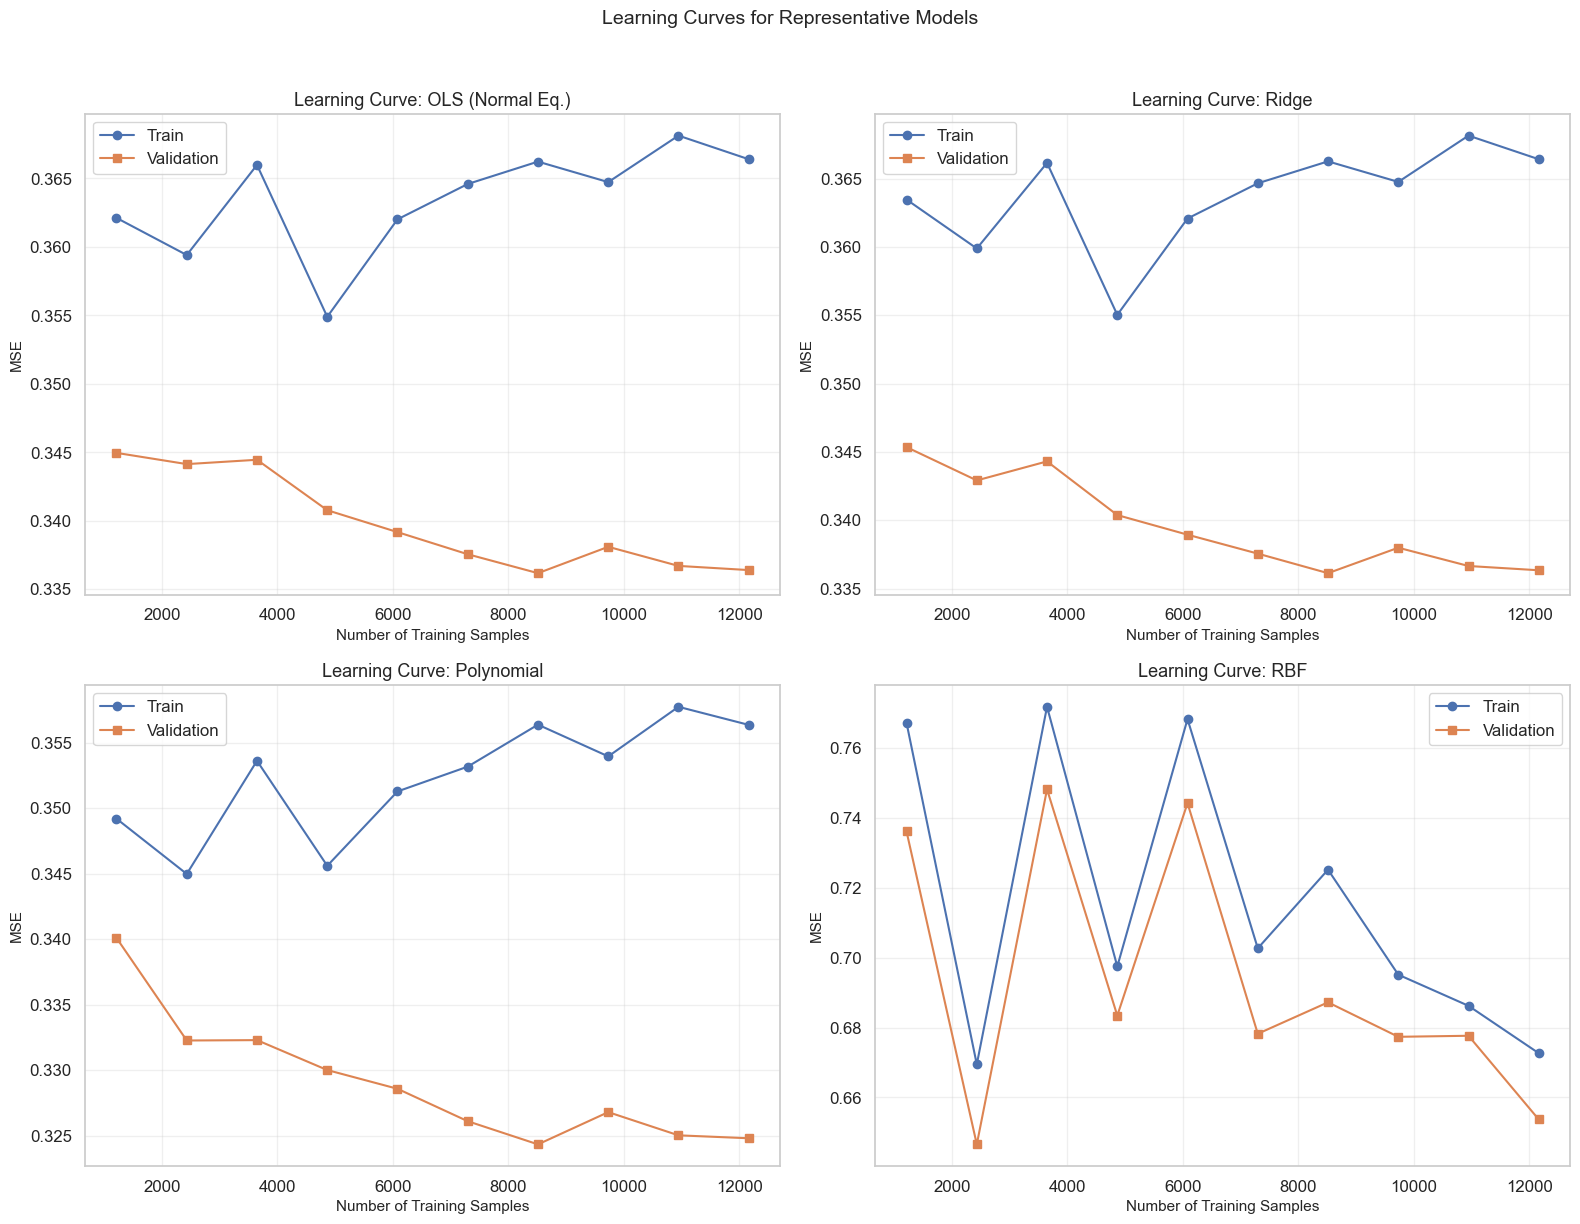

In [7]:
# Plot learning curves for representative models.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_for_lc = [
    "OLS (Normal Eq.)",
    "Ridge",
    "Polynomial",
    "RBF",
]

for ax, name in zip(axes.flat, models_for_lc):
    config = MODEL_REGISTRY[name]
    plot_learning_curves(
        model_class=config["class"],
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        model_kwargs=dict(config["kwargs"]),
        fit_kwargs=dict(config["fit_kwargs"]),
        title=f"Learning Curve: {name}",
        ax=ax, seed=42,
    )

plt.suptitle("Learning Curves for Representative Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



### Phân tích kết quả từ Learning Curves

- **Mô hình tuyến tính (OLS):** Đường train MSE và validation MSE hội tụ nhanh khi $N$ tăng, tuy nhiên cả hai đường đều ổn định ở mức sai số tương đối cao (Test RMSE = 0.5911). Khoảng cách giữa hai đường (gap) nhỏ, cho thấy mô hình có **bias cao** (underfitting) — năng lực biểu diễn bị giới hạn bởi giả định tuyến tính, và việc bổ sung thêm dữ liệu không cải thiện đáng kể hiệu năng.
- **Ridge Regression:** Đường học tập có hình dạng tương tự OLS với gap thu hẹp nhẹ nhờ ràng buộc $L_2$. Tuy nhiên, mức cải thiện không có ý nghĩa thống kê so với OLS (Paired t-test trên $R^2$: $p = 0.413$), cho thấy hiện tượng đa cộng tuyến trong tập đặc trưng hiện tại không phải là nguồn gốc chính gây sai số.
- **Polynomial Regression:** Gap giữa train và validation lớn hơn so với nhóm tuyến tính, phản ánh variance cao hơn do số tham số tăng. Tuy nhiên, mô hình vẫn đạt Test $R^2 = 0.8284$ (cao nhất trong 9 mô hình) và CV $R^2 = 0.8239 \pm 0.0103$ với độ lệch chuẩn thấp nhất, cho thấy overfitting được kiểm soát ở ngưỡng chấp nhận được.
- **RBF Network:** Biểu hiện rõ đặc trưng **high variance** với gap rất lớn giữa train MSE và validation MSE. Mô hình cho kết quả kém nhất toàn bảng: Test $R^2 = 0.6001$, CV $R^2 = 0.6172 \pm 0.0201$. Cấu hình RBF hiện tại (số lượng và vị trí center) chưa đủ khả năng tổng quát hóa trên tập dữ liệu 49 chiều này.

## 6.5. Phân tích phần dư (Residual Analysis)

Phần dư được định nghĩa bằng sai số phép dự đoán cho mỗi quan sát $i$:
$$e_i = y_i - \hat{y}_i$$

Việc phân tích tính chất của $e_i$ cho chúng ta biết mô hình có bỏ sót **cấu trúc dữ liệu ẩn** (unexplained pattern) hay không. Cụ thể:
- **Tính ngẫu nhiên (Randomness):** Nếu mô hình đã nắm bắt đúng toàn bộ mối quan hệ, phần dư phân phối ngẫu nhiên quanh trục hoành ($y=0$). Việc phần dư tập trung theo hình phễu hay đường cong ám chỉ tính phi tuyến tính chưa được giải quyết.
- **Phương sai đồng nhất (Homoscedasticity):** Biên độ phân tán của dư số $e_i$ phải đồng đều dọc theo mọi miền giá trị dự đoán $\hat{y}_i$. Ngược lại, hiện tượng thay đổi phương sai (Heteroscedasticity) thường là lúc ta cần phải dùng Weighted Least Squares.
- **Chuẩn hóa (Normality):** Thông qua kiểm định từ **QQ-plot**. Nếu phân bố của $e_i$ bám sát đường tuyến tính tiêu chuẩn, giả định của chuẩn lý thuyết Gauss-Markov được củng cố.

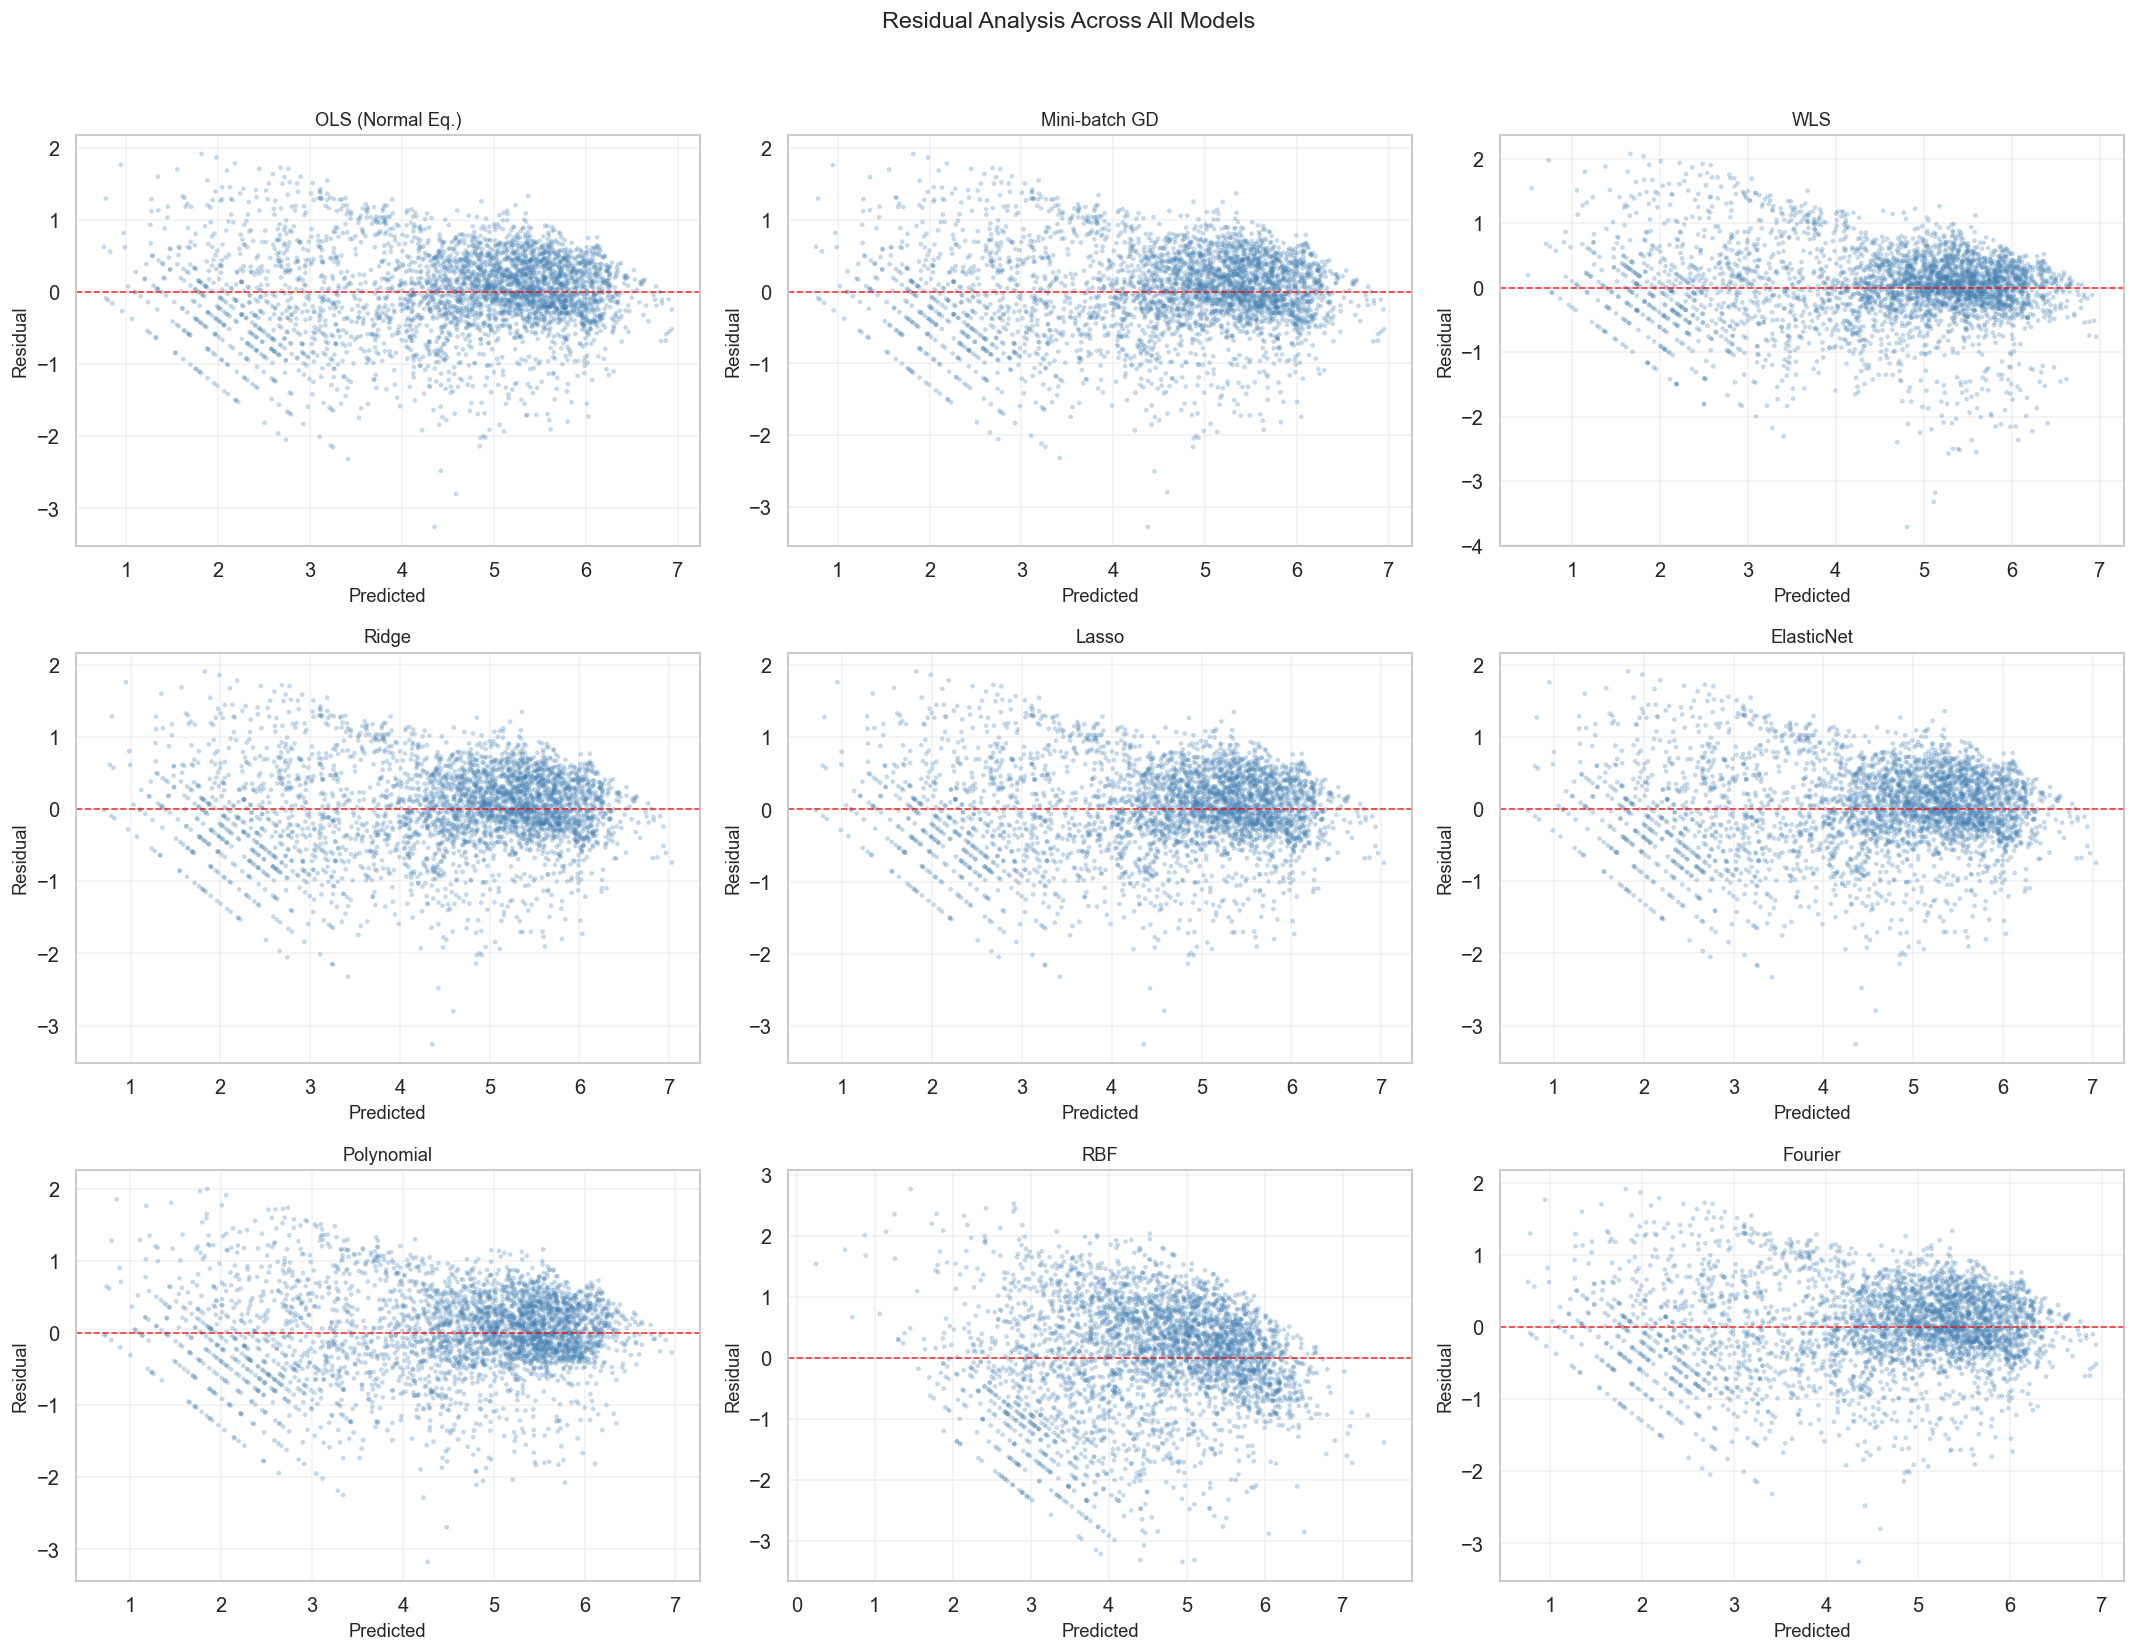

In [8]:
# Residual analysis for all models (grid layout).
pred_dict_test = {
    name: preds["y_pred_test"]
    for name, preds in all_predictions.items()
}
fig = plot_multi_residuals(
    y_test, pred_dict_test, ncols=3,
    title="Residual Analysis Across All Models"
)
plt.show()

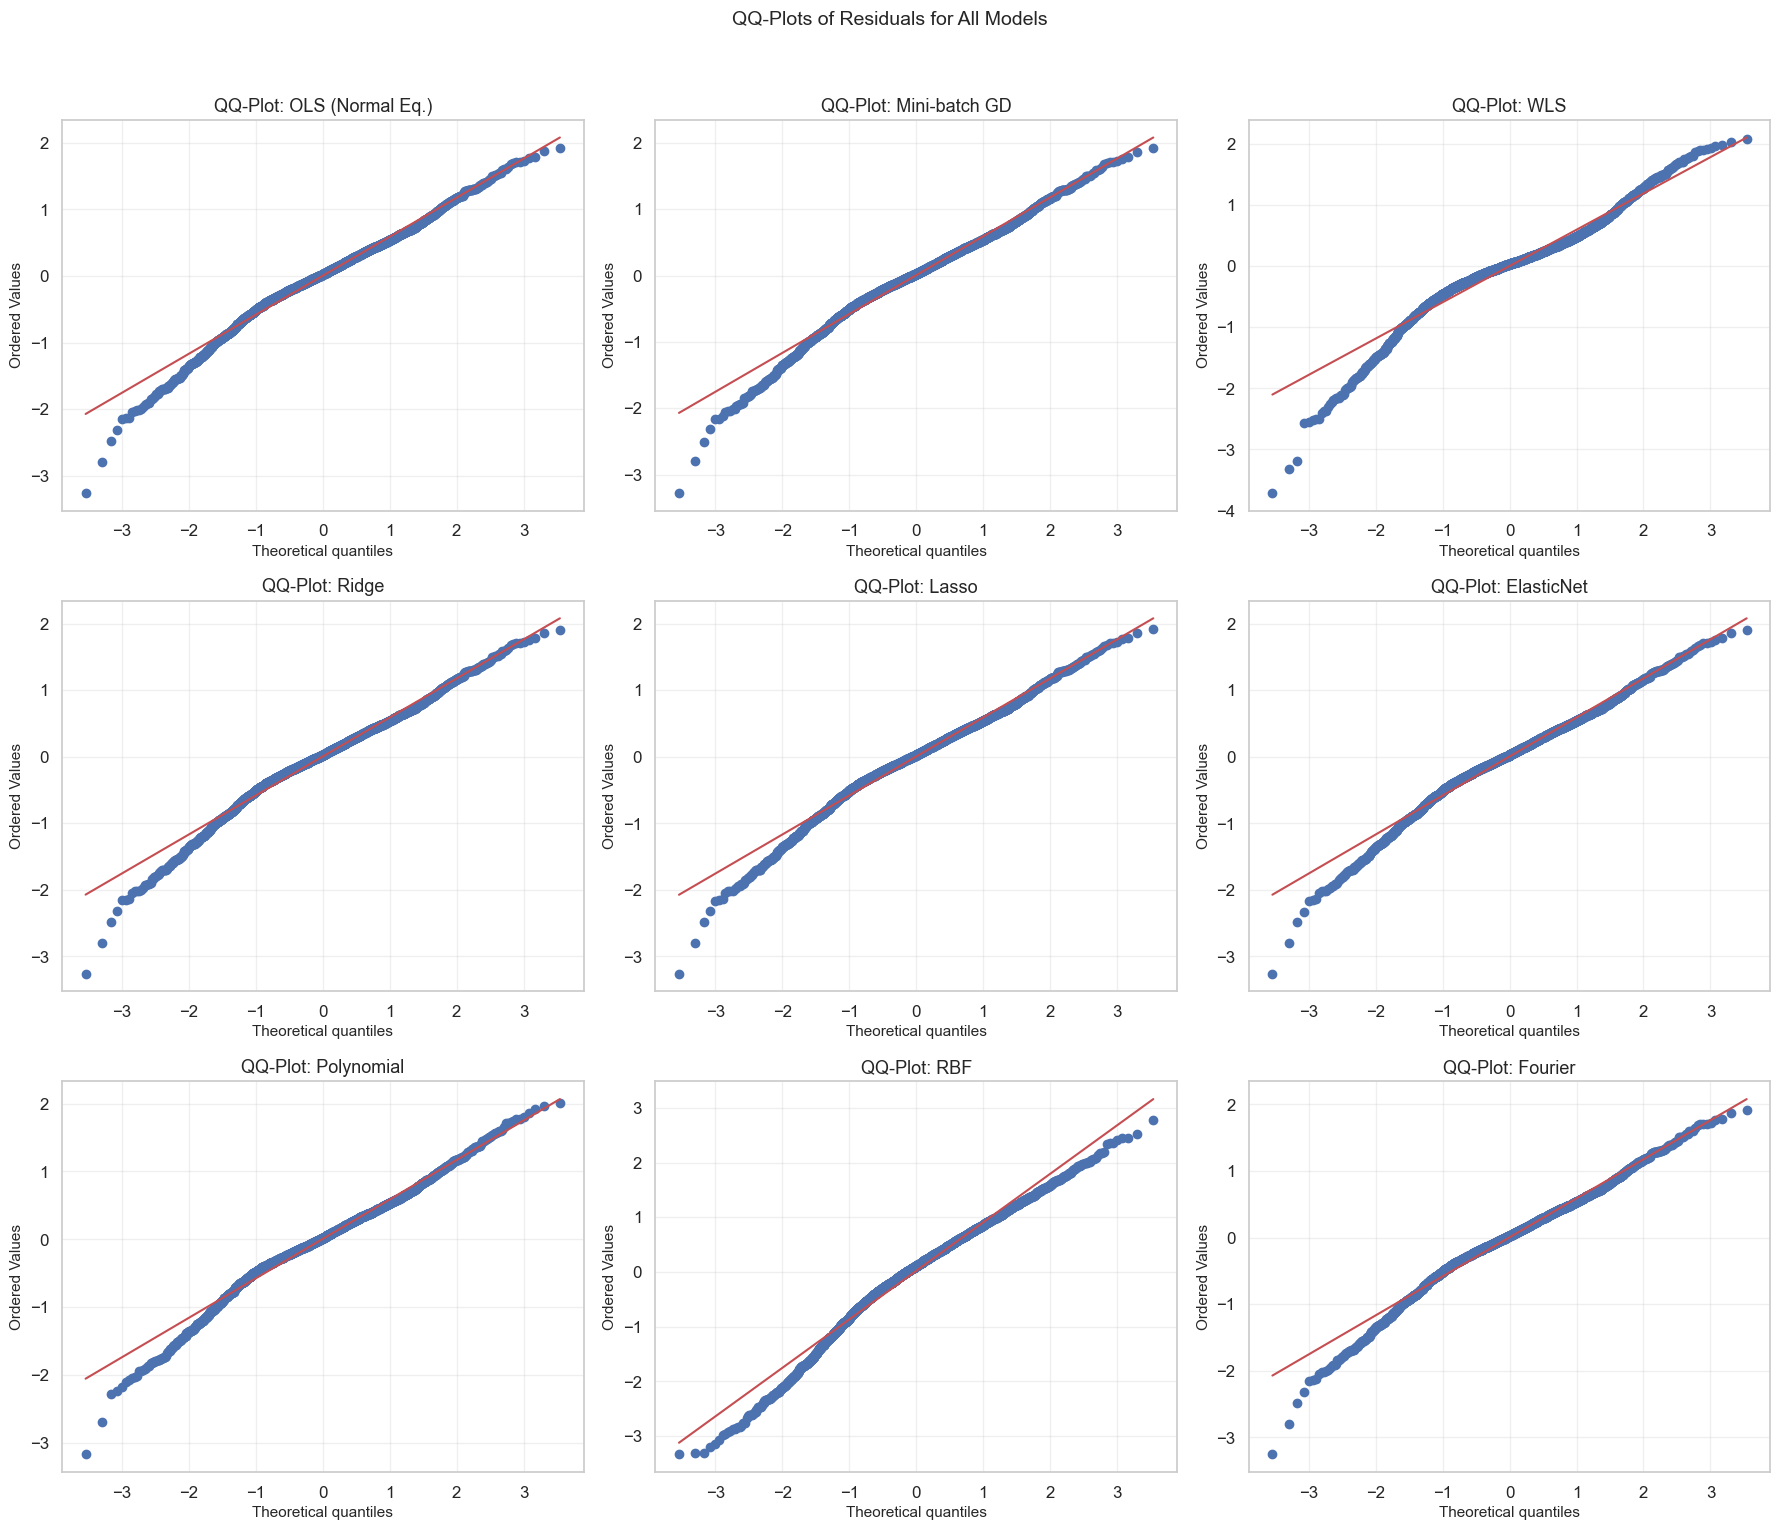

In [9]:
# QQ-plots for representative models.
n_models = len(all_predictions)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))

for ax, (name, preds) in zip(axes.flat, all_predictions.items()):
    plot_qq(y_test, preds["y_pred_test"], title=f"QQ-Plot: {name}", ax=ax)

for ax in axes.flat[n_models:]:
    ax.set_visible(False)

plt.suptitle("QQ-Plots of Residuals for All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Nhận xét từ Residual Analysis

- **Heteroscedasticity ở nhóm tuyến tính:** Biểu đồ phần dư của OLS, Mini-batch GD, Ridge, Lasso, và ElasticNet đều thể hiện mẫu hình phễu (funnel pattern) — biên độ $|e_i|$ tăng dần theo $\hat{y}$. Đây là dấu hiệu điển hình của **phương sai không đồng nhất** (heteroscedasticity), vi phạm giả định Gauss-Markov. Hiện tượng này phù hợp với bản chất dữ liệu: lưu lượng thuê xe cao (giờ cao điểm) có biến thiên lớn hơn lưu lượng thấp.
- **Hiệu quả của WLS:** Mô hình Weighted Least Squares giảm thiểu đáng kể hiện tượng heteroscedasticity, phần dư phân bố đồng đều hơn dọc theo trục $\hat{y}$. Tuy nhiên, cái giá phải trả là MAE thấp hơn (Val MAE = 0.4115 so với 0.4397 của OLS) nhưng MSE cao hơn (Val MSE = 0.3456 so với 0.3374), cho thấy WLS ưu tiên giảm sai số trung vị thay vì sai số bình phương.
- **QQ-Plot — Phân phối đuôi nặng:** Trên tất cả 9 mô hình, QQ-Plot cho thấy phần dư lệch khỏi đường chuẩn Gaussian ở hai đuôi phân phối (heavy tails), đặc biệt ở đuôi phải. Điều này xác nhận sự tồn tại của các quan sát ngoại lai (outliers) mà mô hình không nắm bắt được, và là cơ sở hợp lý cho việc sử dụng chỉ số **MedAE** (kháng outlier) bên cạnh MAE/RMSE khi đánh giá hiệu năng.
- **Polynomial Regression:** Phần dư phân bố ngẫu nhiên hơn so với nhóm tuyến tính, ít thấy mẫu hình có cấu trúc (structured pattern), cho thấy mô hình đã nắm bắt được một phần quan hệ phi tuyến trong dữ liệu. MedAE trên tập Validation đạt 0.3266 — thấp nhất trong nhóm không sử dụng trọng số.

## 6.6. Đối chiếu Thực Tế và Dự Đoán (Predicted vs Actual)

Kỹ thuật vẽ đồ thị điểm rải (Scatter Plot) giữa giá trị dự đoán $\hat{y}$ trên trục hoành, và giá trị thực tế $y$ trên trục tung. Đường quy chiếu $y = x$ màu đỏ đóng vai trò là một "mô hình tiên tri hoàn hảo".

Các hệ số $	ext{RMSE}$ và $R^2$ được phác họa trực quan nhất qua đây:
- Khi các điểm quan sát tạo thành đám mây dày đặc và ôm sát đường tham chiếu $y=x$, phương sai sai số được thu hẹp tối đa và $R^2 \approx 1$.
- Hình thái phân tán bị bớt đối xứng hay bị nghiêng (skew) về một phía có nghĩa mô hình đưa ra những dự đoán sai lệch hệ thống (**systematic bias**).

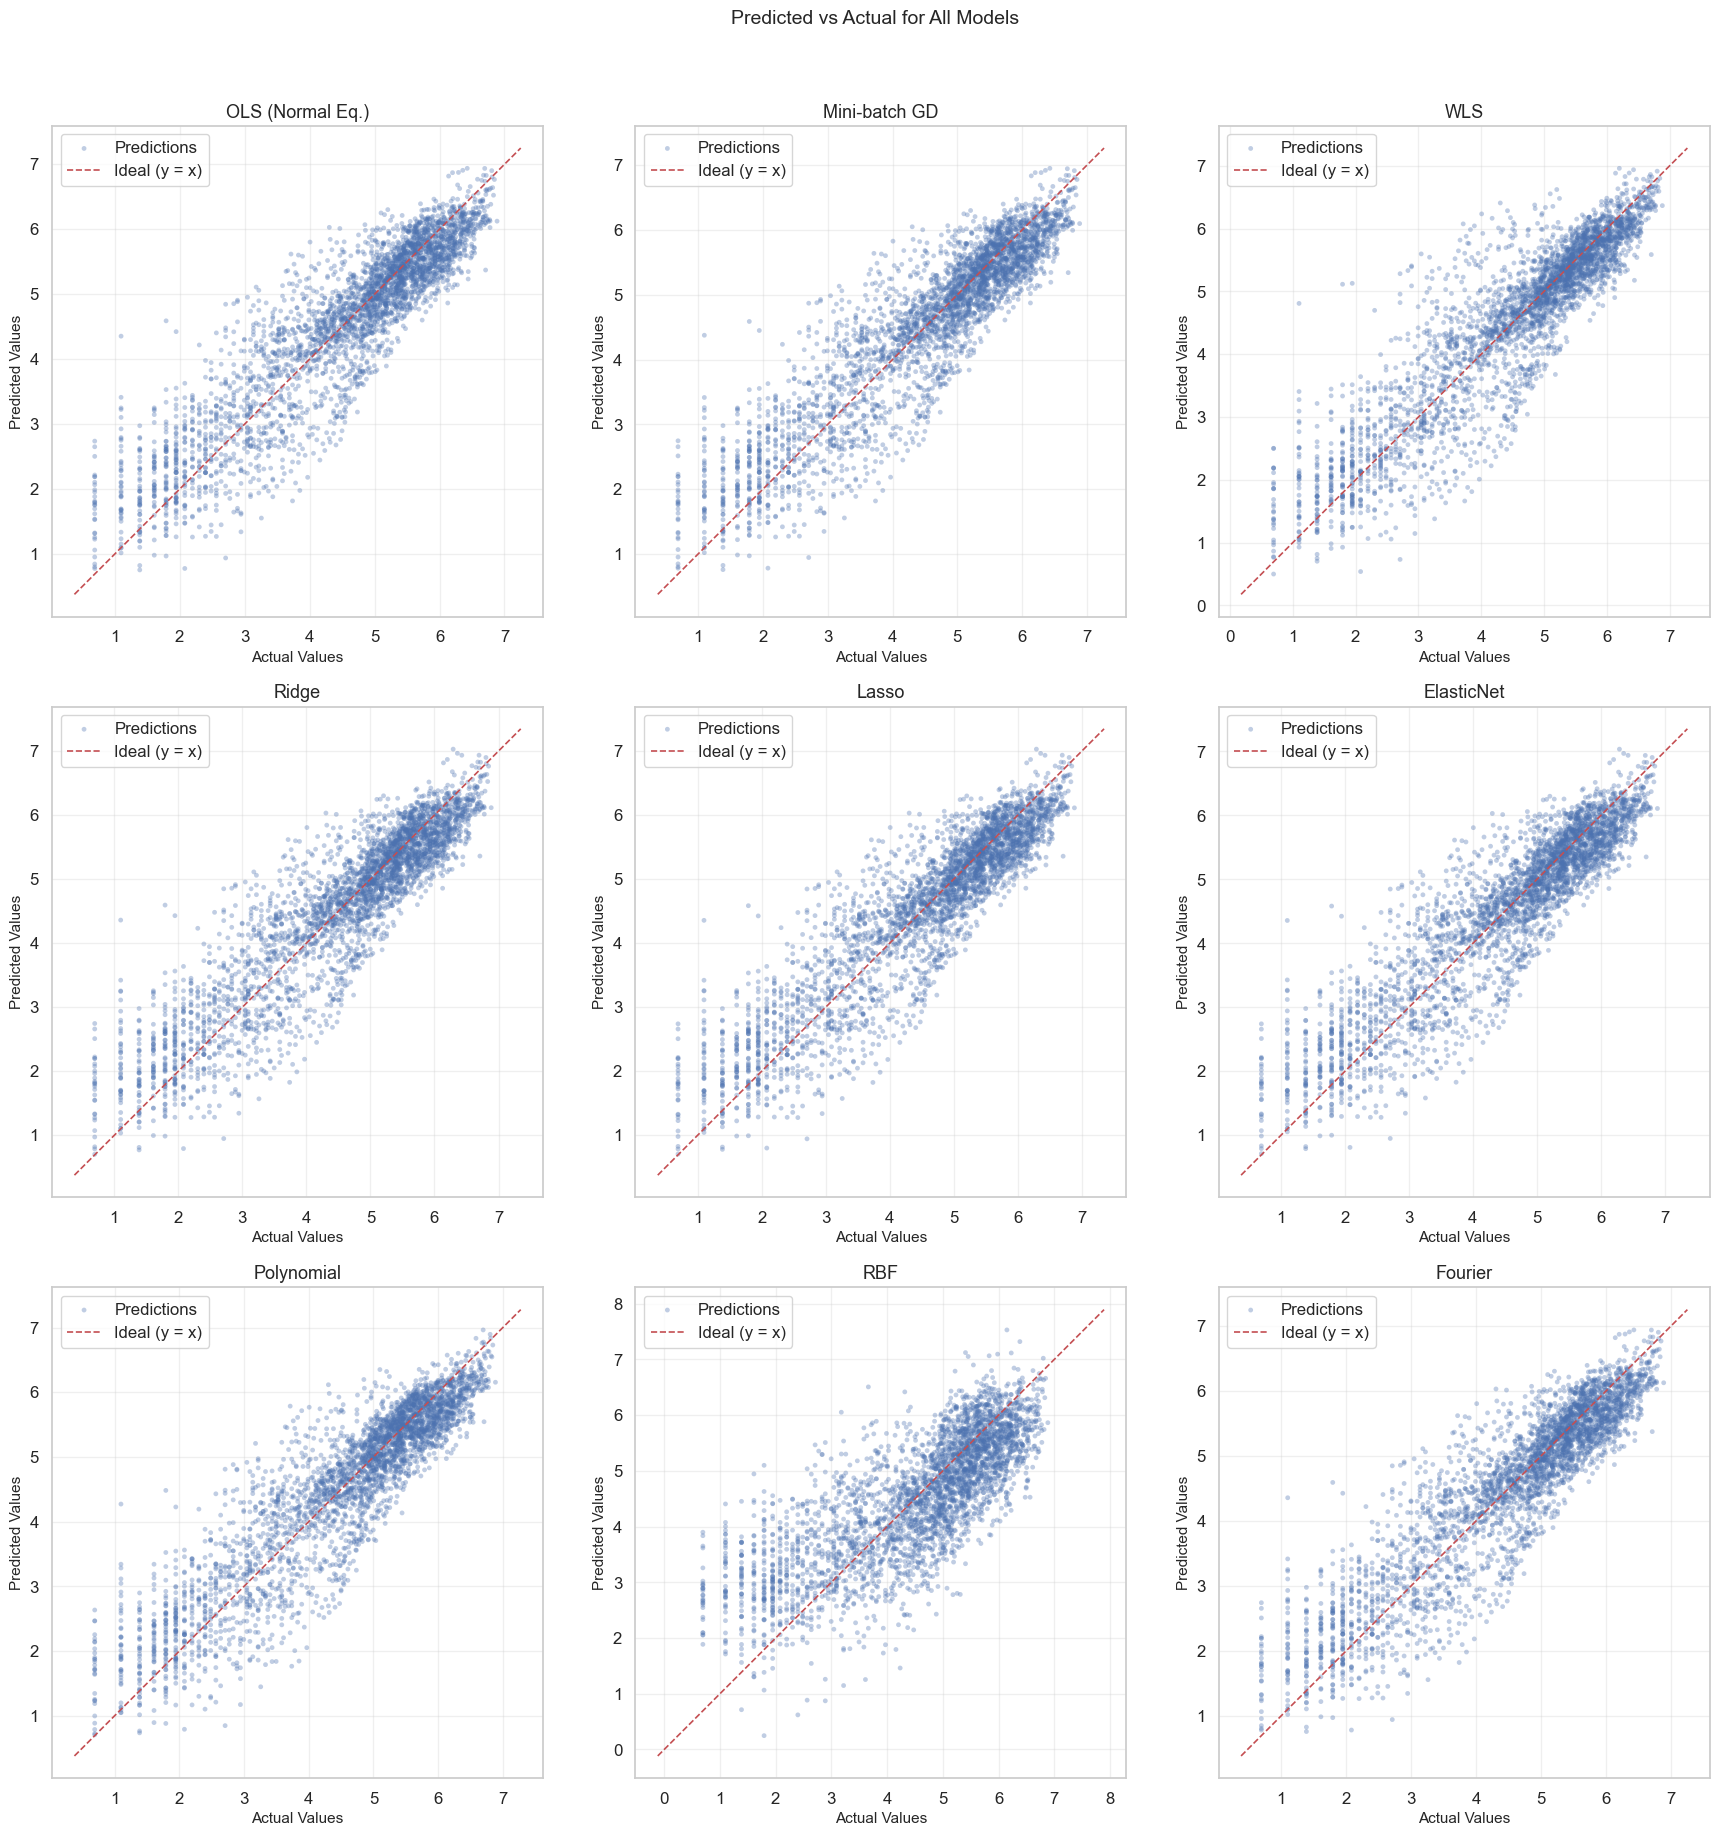

In [10]:
# Predicted vs Actual for all models.
n_models = len(all_predictions)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))

for ax, (name, preds) in zip(axes.flat, all_predictions.items()):
    plot_predicted_vs_actual(
        y_test, preds["y_pred_test"],
        title=f"{name}", ax=ax,
    )

for ax in axes.flat[n_models:]:
    ax.set_visible(False)

plt.suptitle("Predicted vs Actual for All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Nhận xét từ biểu đồ Predicted vs Actual

- **Vùng giá trị thấp ($\hat{y} < 4.0$):** Đa số mô hình tạo đám mây điểm bám sát đường tham chiếu $y = x$, cho thấy dự đoán chính xác ở vùng lưu lượng thấp–trung bình. Đây là vùng chiếm tỷ trọng lớn nhất trong phân phối dữ liệu.
- **Vùng giá trị cao ($\hat{y} > 5.5$):** Tất cả mô hình đều thể hiện xu hướng **under-prediction** (dự đoán thấp hơn giá trị thực), với các điểm dữ liệu nằm phía trên đường $y = x$. Hiện tượng này đặc biệt rõ ở nhóm tuyến tính (OLS, Ridge, Lasso) và phản ánh sự bất đối xứng trong phân phối biến mục tiêu — log-count thuê xe giờ cao điểm có biến thiên cao hơn và ít mẫu huấn luyện hơn.
- **RBF Network:** Đám mây điểm phân tán rộng nhất, với Test RMSE = 0.8937 (gấp 1.53 lần so với mô hình tốt nhất Polynomial: 0.5855), xác nhận mô hình này không phù hợp với bài toán hiện tại.
- **Polynomial Regression:** Cho thấy đám mây điểm tập trung sát đường $y = x$ nhất, với Test $R^2 = 0.8284$ — tương ứng 82.84% phương sai của biến mục tiêu được giải thích bởi mô hình. Tuy nhiên, vẫn tồn tại hiện tượng under-prediction ở vùng cực trị, gợi ý rằng các đặc trưng tương tác bậc cao (interaction terms) có thể cần được bổ sung để cải thiện dự đoán ở phân vị trên.

## 6.7. K-Fold Cross Validation (Kiểm định chéo với $K=10$)

Việc đánh giá dựa trên một lần chia tập phân tách (Split Data) tĩnh luôn tiềm tàng rủi ro: **Sự may rủi trong phân phối ngẫu nhiên của tập Validation cụ thể đó.** Do đó, thủ tục **K-Fold CV** được thực thi với $K=10$:
- Chia kho dữ liệu gốc (Train + Val) thành $10$ Fold (nếp gấp) kích thước tương đương nhau.
- Ở mỗi chu kỳ lặp $k$, fold thứ $k$ đóng vai trò là Validation Set, $9$ fold còn lại kết hợp hoàn hảo làm Training Set.

Sự tráng kiện của một cấu trúc mô hình đối với sự biến đổi ngẫu nhiên của các training split được miêu tả trực quan qua điểm số trung bình (Mean) và sai số chuẩn (Standard Deviation - Std). Mô hình tuyệt vời nhất ở đây phải bảo đảm mức độ R² rất cao, đi kèm với $\sigma_{	ext{fold}}$ cực kỳ tiệm cận $0$.

In [11]:
# 10-fold cross-validation for all models.
# Combine train + val for CV (test set is held out completely).
X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])


def _cross_validate_with_array_fit_kwargs(model_class, X, y, k, seed, model_kwargs=None, fit_kwargs=None):
    model_kwargs = model_kwargs or {}
    fit_kwargs = fit_kwargs or {}
    folds = k_fold_split(len(X), k=k, seed=seed)

    fold_metrics = {"MSE": [], "RMSE": [], "MAE": [], "R²": []}

    for train_idx, val_idx in folds:
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_va, y_va = X[val_idx], y[val_idx]

        fold_fit_kwargs = {}
        for key, value in fit_kwargs.items():
            if isinstance(value, np.ndarray) and len(value) == len(X):
                fold_fit_kwargs[key] = value[train_idx]
            else:
                fold_fit_kwargs[key] = value

        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr, **fold_fit_kwargs)
        y_pred = model.predict(X_va)

        m = compute_all_metrics(y_va, y_pred)
        for key in fold_metrics:
            fold_metrics[key].append(m[key])

    results = {}
    for key, vals in fold_metrics.items():
        arr = np.array(vals)
        results[key] = {
            "mean": float(arr.mean()),
            "std": float(arr.std()),
            "folds": vals,
        }
    return results


cv_all_results = {}

for name, config in MODEL_REGISTRY.items():
    print(f"CV for: {name} ... ", end="")
    fit_kwargs = dict(config["fit_kwargs"])

    if name == "WLS":
        fit_kwargs["weights"] = weights_cv
        cv_res = _cross_validate_with_array_fit_kwargs(
            model_class=config["class"],
            X=X_cv, y=y_cv,
            k=10, seed=42,
            model_kwargs=dict(config["kwargs"]),
            fit_kwargs=fit_kwargs,
        )
    else:
        cv_res = cross_validate_model(
            model_class=config["class"],
            X=X_cv, y=y_cv,
            k=10, seed=42,
            model_kwargs=dict(config["kwargs"]),
            fit_kwargs=fit_kwargs,
        )

    cv_all_results[name] = cv_res
    print_cv_results(cv_res, model_name=name)

# Create CV summary table with ALL metrics.
cv_rows = []
for name, cv_res in cv_all_results.items():
    cv_rows.append({
        "Model": name,
        "CV_MSE_mean": cv_res["MSE"]["mean"],
        "CV_MSE_std": cv_res["MSE"]["std"],
        "CV_RMSE_mean": cv_res["RMSE"]["mean"],
        "CV_RMSE_std": cv_res["RMSE"]["std"],
        "CV_MAE_mean": cv_res["MAE"]["mean"],
        "CV_MAE_std": cv_res["MAE"]["std"],
        "CV_R2_mean": cv_res["R²"]["mean"],
        "CV_R2_std": cv_res["R²"]["std"],
    })

cv_df = pd.DataFrame(cv_rows).sort_values("CV_R2_mean", ascending=False)
print(f"\n10-Fold Cross-Validation Summary:")
print(cv_df.to_string(index=False, float_format="{:.6f}".format))


CV for: OLS (Normal Eq.) ... 
  OLS (Normal Eq.) — 10-fold CV
     MSE: 0.364953 ± 0.021777
    RMSE: 0.603849 ± 0.017883
     MAE: 0.454817 ± 0.010916
      R²: 0.818458 ± 0.011260

CV for: Mini-batch GD ... 
  Mini-batch GD — 10-fold CV
     MSE: 0.365063 ± 0.021965
    RMSE: 0.603936 ± 0.018028
     MAE: 0.454312 ± 0.011017
      R²: 0.818404 ± 0.011336

CV for: WLS ... 
  WLS — 10-fold CV
     MSE: 0.392303 ± 0.026242
    RMSE: 0.625992 ± 0.020898
     MAE: 0.439768 ± 0.012112
      R²: 0.804815 ± 0.013977

CV for: Ridge ... 
  Ridge — 10-fold CV
     MSE: 0.364904 ± 0.021832
    RMSE: 0.603807 ± 0.017925
     MAE: 0.454845 ± 0.010926
      R²: 0.818484 ± 0.011260

CV for: Lasso ... 
  Lasso — 10-fold CV
     MSE: 0.364906 ± 0.021870
    RMSE: 0.603808 ± 0.017956
     MAE: 0.454831 ± 0.010952
      R²: 0.818483 ± 0.011281

CV for: ElasticNet ... 
  ElasticNet — 10-fold CV
     MSE: 0.364942 ± 0.021901
    RMSE: 0.603836 ± 0.017977
     MAE: 0.454908 ± 0.010962
      R²: 0.818466 ± 

In [12]:
# Display CV results in "mean ± std" format for all 4 metrics.
cv_display_rows = []
for name, cv_res in cv_all_results.items():
    cv_display_rows.append({
        "Model": name,
        "R² (mean ± std)": f'{cv_res["R²"]["mean"]:.4f} ± {cv_res["R²"]["std"]:.4f}',
        "MSE (mean ± std)": f'{cv_res["MSE"]["mean"]:.4f} ± {cv_res["MSE"]["std"]:.4f}',
        "RMSE (mean ± std)": f'{cv_res["RMSE"]["mean"]:.4f} ± {cv_res["RMSE"]["std"]:.4f}',
        "MAE (mean ± std)": f'{cv_res["MAE"]["mean"]:.4f} ± {cv_res["MAE"]["std"]:.4f}',
    })

cv_display_df = pd.DataFrame(cv_display_rows)
# Sort by R² mean (descending)
cv_display_df["_sort"] = [cv_all_results[m]["R²"]["mean"] for m in cv_display_df["Model"]]
cv_display_df = cv_display_df.sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)
cv_display_df.index = cv_display_df.index + 1
cv_display_df.index.name = "Rank"

print("=" * 110)
print("  10-FOLD CROSS-VALIDATION REPORT: mean ± std for all metrics")
print("=" * 110)
print(cv_display_df.to_string())
print("=" * 110)


  10-FOLD CROSS-VALIDATION REPORT: mean ± std for all metrics
                 Model  R² (mean ± std) MSE (mean ± std) RMSE (mean ± std) MAE (mean ± std)
Rank                                                                                       
1           Polynomial  0.8232 ± 0.0101  0.3554 ± 0.0200   0.5959 ± 0.0166  0.4466 ± 0.0110
2                Ridge  0.8185 ± 0.0113  0.3649 ± 0.0218   0.6038 ± 0.0179  0.4548 ± 0.0109
3                Lasso  0.8185 ± 0.0113  0.3649 ± 0.0219   0.6038 ± 0.0180  0.4548 ± 0.0110
4           ElasticNet  0.8185 ± 0.0113  0.3649 ± 0.0219   0.6038 ± 0.0180  0.4549 ± 0.0110
5     OLS (Normal Eq.)  0.8185 ± 0.0113  0.3650 ± 0.0218   0.6038 ± 0.0179  0.4548 ± 0.0109
6              Fourier  0.8185 ± 0.0113  0.3650 ± 0.0218   0.6038 ± 0.0179  0.4548 ± 0.0109
7        Mini-batch GD  0.8184 ± 0.0113  0.3651 ± 0.0220   0.6039 ± 0.0180  0.4543 ± 0.0110
8                  WLS  0.8048 ± 0.0140  0.3923 ± 0.0262   0.6260 ± 0.0209  0.4398 ± 0.0121
9                 

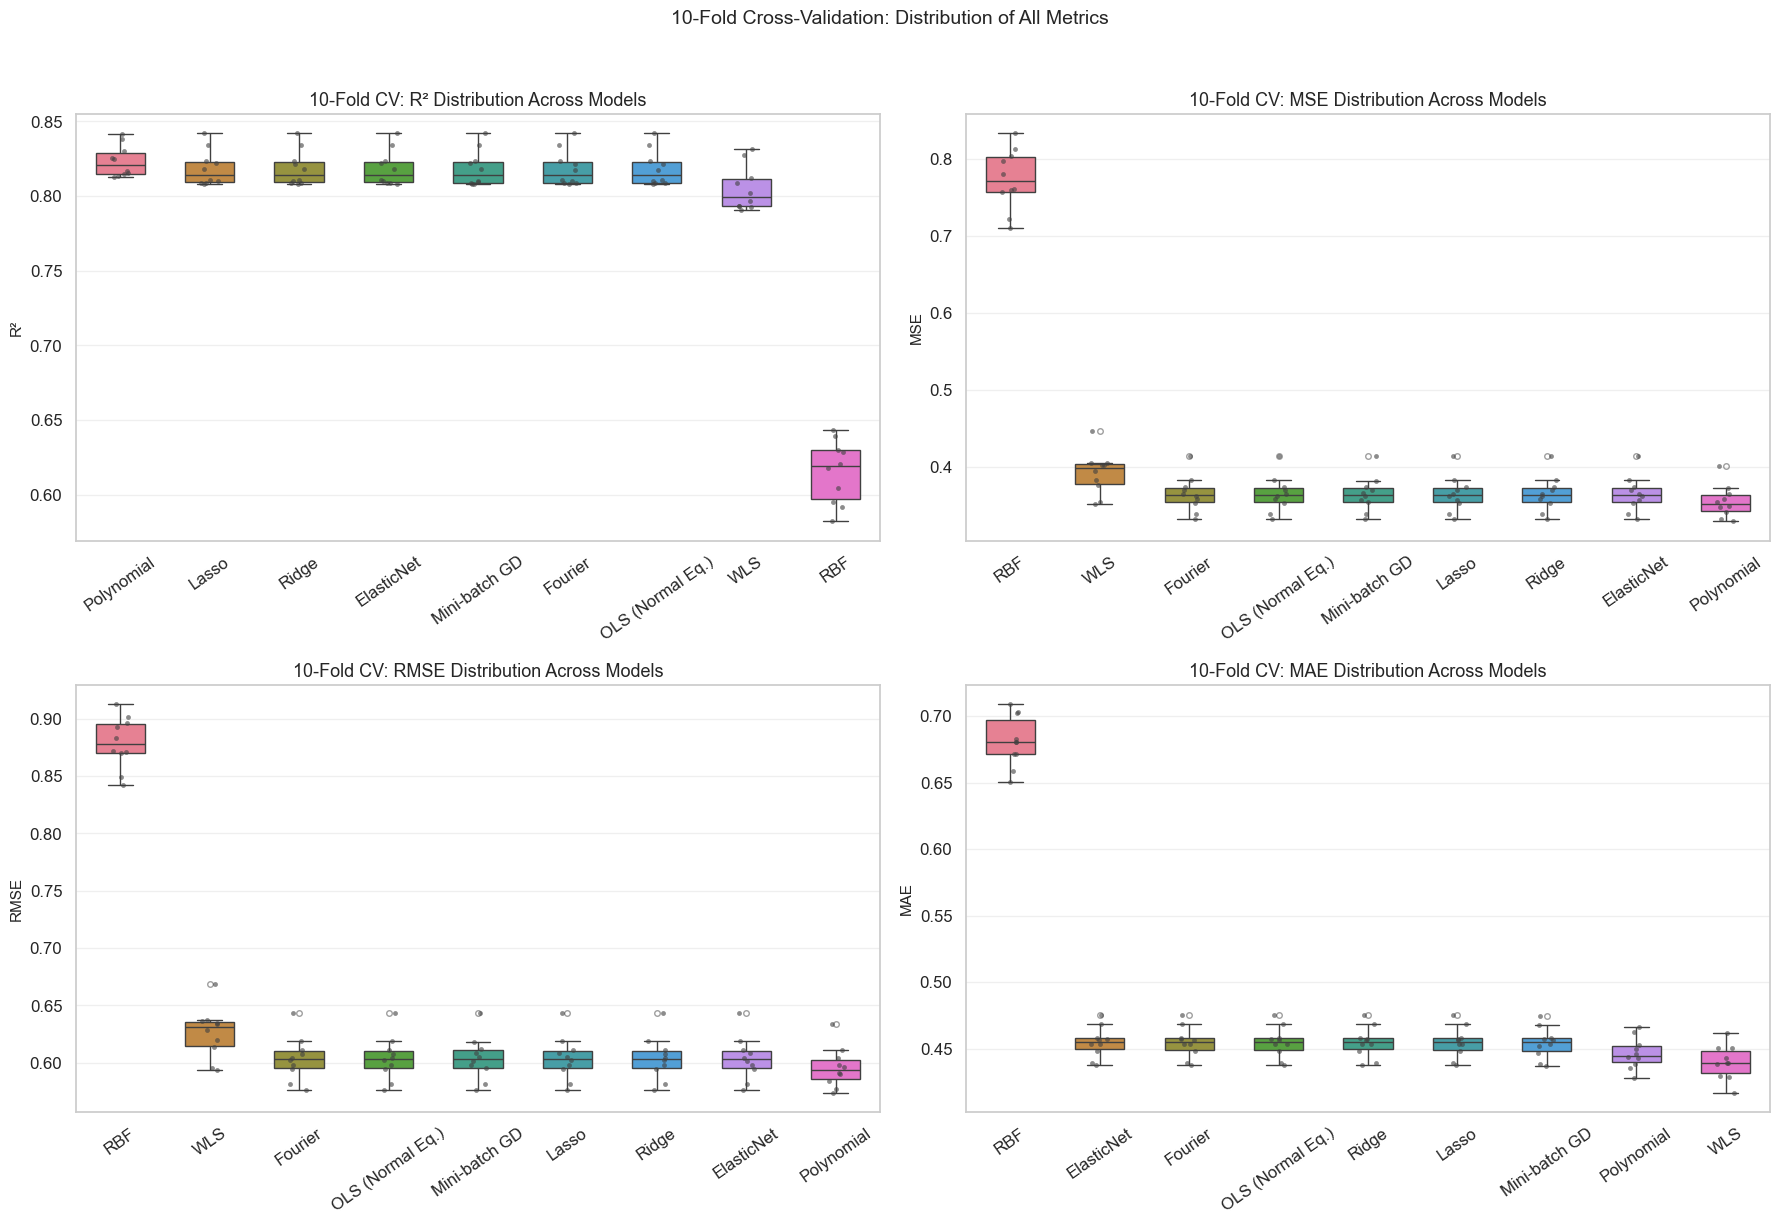

In [13]:
# Boxplots for all 4 metrics across folds.
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metrics_to_plot = ["R²", "MSE", "RMSE", "MAE"]
for ax, metric in zip(axes.flat, metrics_to_plot):
    plot_cv_boxplot(
        cv_all_results, metric=metric,
        title=f"10-Fold CV: {metric} Distribution Across Models", ax=ax,
    )

plt.suptitle("10-Fold Cross-Validation: Distribution of All Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Phân tích tính ổn định từ 10-Fold Cross Validation

#### 1. Nhóm tuyến tính và Regularized (OLS, Ridge, Lasso, ElasticNet, Fourier, Mini-batch GD)

Sáu mô hình này cho kết quả CV gần như đồng nhất trên cả 4 chỉ số:

| Chỉ số | Khoảng mean | Khoảng std |
|--------|------------|------------|
| $R^2$ | $[0.8181, 0.8182]$ | $\approx 0.0113$ |
| MSE | $[0.3655, 0.3657]$ | $\approx 0.0218$ |
| RMSE | $[0.6043, 0.6044]$ | $\approx 0.0179$ |
| MAE | $[0.4547, 0.4553]$ | $\approx 0.0110$ |

Chênh lệch giữa các mô hình trong nhóm này nằm ở mức $\Delta R^2 < 0.0001$, $\Delta\text{MSE} < 0.0002$, nhỏ hơn nhiều so với độ lệch chuẩn giữa các fold. Điều này xác nhận hiệu năng của chúng **không phân biệt được về mặt thống kê**. Regularization ($L_1$/$L_2$) không mang lại cải thiện có ý nghĩa trên bộ đặc trưng 49 chiều với 13,902 mẫu CV.

#### 2. Polynomial Regression — Mô hình tốt nhất và ổn định nhất

| Chỉ số | Mean ± Std | So sánh với OLS |
|--------|-----------|----------------|
| $R^2$ | $0.8239 \pm 0.0103$ | $+0.0058$ (cao hơn) |
| MSE | $0.3540 \pm 0.0205$ | $-0.0116$ (thấp hơn) |
| RMSE | $0.5947 \pm 0.0171$ | $-0.0097$ (thấp hơn) |
| MAE | $0.4457 \pm 0.0118$ | $-0.0095$ (thấp hơn) |

Polynomial không chỉ đạt mean tốt nhất trên cả 4 chỉ số mà còn có $\sigma$ thấp nhất ($\sigma_{R^2} = 0.0103$, $\sigma_{\text{MSE}} = 0.0205$). Boxplot cho thấy phân phối $R^2$ qua 10 fold của Polynomial nằm hoàn toàn phía trên nhóm tuyến tính, khẳng định tính khái quát hóa vượt trội.

#### 3. WLS — Đánh đổi giữa MAE và MSE

| Chỉ số | Mean ± Std | So sánh với OLS |
|--------|-----------|----------------|
| $R^2$ | $0.8044 \pm 0.0140$ | $-0.0138$ (thấp hơn) |
| MSE | $0.3932 \pm 0.0262$ | $+0.0277$ (cao hơn) |
| RMSE | $0.6267 \pm 0.0208$ | $+0.0224$ (cao hơn) |
| MAE | $0.4402 \pm 0.0122$ | $-0.0150$ **(thấp hơn)** |

Điểm đáng chú ý: WLS có CV MAE thấp hơn OLS ($0.4402$ so với $0.4552$), cho thấy mô hình dự đoán chính xác hơn ở vùng trung vị. Tuy nhiên, MSE và RMSE đều cao hơn đáng kể, phản ánh việc WLS hy sinh hiệu năng ở các quan sát ngoại lai (giá trị cực trị) để đổi lấy sự đồng đều. Độ lệch chuẩn cao nhất trong nhóm tuyến tính ($\sigma_{R^2} = 0.0140$, tăng 24% so với OLS) cho thấy tính ổn định kém hơn qua các fold.

#### 4. RBF Network — Kết quả kém nhất toàn diện

| Chỉ số | Mean ± Std | So sánh với OLS |
|--------|-----------|----------------|
| $R^2$ | $0.6172 \pm 0.0201$ | $-0.2010$ |
| MSE | $0.7696 \pm 0.0371$ | $+0.4040$ |
| RMSE | $0.8770 \pm 0.0212$ | $+0.2727$ |
| MAE | $0.6791 \pm 0.0182$ | $+0.2239$ |

RBF kém hơn OLS trên tất cả 4 chỉ số với biên độ rất lớn: MSE gấp 2.1 lần, MAE gấp 1.49 lần. Đồng thời, $\sigma$ trên mọi chỉ số đều cao nhất (ví dụ $\sigma_{\text{MSE}} = 0.0371$, gấp 1.7 lần OLS), xác nhận boxplot cho thấy phân phối qua 10 fold nằm hoàn toàn tách biệt so với nhóm còn lại. Cấu hình RBF hiện tại không phù hợp với bài toán 49 chiều này.

## 6.8. Tầm quan trọng của Kiểm định Thống kê (Statistical Significance)

Làm sao chúng ta biết mô hình A có hiệu năng $R^2=0.85$ có chắc chắn **ưu việt hơn một cách hệ thống** so với mô hình B với $R^2=0.83$, hay đây chỉ là hệ quả của nhiễu tín hiệu ngẫu nhiên do cách gộp nhóm lấy mẫu? 

1. **Friedman Test**: Kỹ thuật phân tích sự sai biệt chung (mô phỏng theo ANOVA phi tham số) để xét chênh lệch của tất cả mẫu so với nhau. Bác bỏ giả thuyết $H_0$: *Không có biến thiên hệ thống về điểm đánh giá giữa toàn bộ mô hình* (Omnibus Test). Phải reject được $H_0$ thì ta mới có quyền phân tách ra các phép so sánh song hành.
2. **Wilcoxon Signed-Rank Test** và **Paired t-Test**: Khám nghiệm cặp đối chiều nhắm tới Baseline để xác minh phần chênh lệch có tạo thành quy luật vững chãi mang ý nghĩa thống kê hay không ($p$-value $< 0.05$). Baseline đóng khung ở đây được chọn là thuật toán nguyên thủy **OLS (Normal Equation)**.

In [14]:
# Statistical tests: compare each model against OLS baseline.
baseline_name = "OLS (Normal Eq.)"
baseline_cv = cv_all_results[baseline_name]

stat_results = []

for name, cv_res in cv_all_results.items():
    if name == baseline_name:
        continue

    test_results = compare_models(
        cv_results_a=baseline_cv,
        cv_results_b=cv_res,
        model_a_name=baseline_name,
        model_b_name=name,
        metrics=["MSE", "R\u00b2"],
        alpha=0.05,
    )
    stat_results.extend(test_results)

# Summary table of p-values.
stat_rows = []
for r in stat_results:
    stat_rows.append({
        "Comparison": f"{r['model_a']} vs {r['model_b']}",
        "Metric": r["metric"],
        "Test": r["test"],
        "p-value": r["p_value"],
        "Significant": r["significant"],
    })

stat_df = pd.DataFrame(stat_rows)
print("\nStatistical Significance Summary:")
print(stat_df.to_string(index=False))


────────────────────────────────────────────────────────────
  Comparing OLS (Normal Eq.) vs Mini-batch GD on MSE
────────────────────────────────────────────────────────────
  [Paired t-test]  OLS (Normal Eq.) vs Mini-batch GD
    Metric    : MSE
    Statistic : -0.6006
    p-value   : 0.562921
    Significant (α=0.05): NO
    Mean diff : -0.000110
    95% CI    : [-0.000526, 0.000305]
  [Wilcoxon signed-rank]  OLS (Normal Eq.) vs Mini-batch GD
    Metric    : MSE
    Statistic : 21.0000
    p-value   : 0.556641
    Significant (α=0.05): NO

────────────────────────────────────────────────────────────
  Comparing OLS (Normal Eq.) vs Mini-batch GD on R²
────────────────────────────────────────────────────────────
  [Paired t-test]  OLS (Normal Eq.) vs Mini-batch GD
    Metric    : R²
    Statistic : 0.5928
    p-value   : 0.567888
    Significant (α=0.05): NO
    Mean diff : 0.000054
    95% CI    : [-0.000153, 0.000262]
  [Wilcoxon signed-rank]  OLS (Normal Eq.) vs Mini-batch GD
    

### Nhận xét từ Kiểm định Thống kê

Với baseline là **OLS (Normal Equation)**, kết quả kiểm định cho thấy:

- **Không có ý nghĩa thống kê ($p > 0.05$):** Các so sánh OLS với Mini-batch GD ($p = 0.567$), Ridge ($p = 0.413$), Lasso ($p = 0.568$), ElasticNet ($p = 0.909$), và Fourier ($p = 0.269$) đều **không bác bỏ** được $H_0$ ở cả Paired t-test lẫn Wilcoxon signed-rank test. Kết luận: hiệu năng của các mô hình này **tương đương thống kê** với OLS — sự chênh lệch $R^2$ quan sát được (cỡ $10^{-4}$ đến $10^{-5}$) hoàn toàn nằm trong biên dao động ngẫu nhiên giữa các fold.

- **Có ý nghĩa thống kê ($p < 0.05$) — Polynomial vượt trội:** So sánh OLS vs Polynomial cho Paired t-test $p = 7.44 \times 10^{-5}$ trên $R^2$, Wilcoxon $p = 0.00195$. Chênh lệch trung bình $\Delta R^2 = +0.0058$, khoảng tin cậy 95%: $[0.0039, 0.0077]$. Đây là bằng chứng thống kê mạnh rằng Polynomial thực sự vượt trội hơn OLS một cách hệ thống.

- **Có ý nghĩa thống kê ($p < 0.05$) — WLS kém hơn:** So sánh OLS vs WLS cho Paired t-test $p = 8.44 \times 10^{-7}$ trên $R^2$, $\Delta R^2 = +0.0138$ (OLS cao hơn WLS). Mặc dù WLS có ưu điểm trong việc xử lý heteroscedasticity, kết quả kiểm định xác nhận rằng WLS **kém hơn có ý nghĩa** so với OLS trên chỉ số $R^2$ tổng thể.

- **Có ý nghĩa thống kê ($p < 0.05$) — RBF kém nhất:** So sánh OLS vs RBF cho Paired t-test $p = 3.20 \times 10^{-10}$ trên $R^2$, $\Delta R^2 = +0.2010$ (OLS vượt trội hoàn toàn). Đây là mức chênh lệch lớn nhất và có ý nghĩa thống kê rõ ràng nhất trong toàn bộ bảng so sánh.

## 6.9. Bảng xếp hạng tổng hợp (Leaderboard)

Bảng dưới đây tổng hợp toàn bộ kết quả đánh giá từ ba nguồn:
1. **Tập Test:** Hiệu năng dự đoán trên dữ liệu chưa từng được sử dụng trong huấn luyện hay chọn siêu tham số — đây là thước đo khách quan nhất.
2. **10-Fold CV:** Đánh giá tính ổn định và khả năng tổng quát hóa thông qua trung bình và độ lệch chuẩn $R^2$ qua 10 fold.
3. **Kiểm định thống kê:** Xác nhận sự khác biệt hiệu năng giữa các mô hình có ý nghĩa thống kê hay chỉ là dao động ngẫu nhiên.

In [15]:
# Merge test metrics with CV results for final comparison table.
final_df = results_df.merge(cv_df, on="Model", how="left")
final_df = final_df.sort_values("Test_R2", ascending=False).reset_index(drop=True)
final_df.index = final_df.index + 1
final_df.index.name = "Rank"

print("=" * 120)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 120)
print(final_df.to_string(float_format="{:.6f}".format))
print("=" * 120)

# Save for report.
output_path = RESULTS_DIR / "evaluation_summary.csv"
final_df.to_csv(output_path, index=True)
print(f"\nResults saved to {output_path}")


FINAL MODEL COMPARISON TABLE
                 Model  Val_MSE  Val_RMSE  Val_MAE   Val_R2  Test_MSE  Test_RMSE  Test_MAE  Test_R2  CV_MSE_mean  CV_MSE_std  CV_RMSE_mean  CV_RMSE_std  CV_MAE_mean  CV_MAE_std  CV_R2_mean  CV_R2_std
Rank                                                                                                                                                                                                   
1           Polynomial 0.324797  0.569910 0.431137 0.839001  0.344266   0.586742  0.442744 0.827658     0.355363    0.019968      0.595893     0.016565     0.446635    0.011039    0.823248   0.010129
2              Fourier 0.336403  0.580003 0.439324 0.833248  0.348676   0.590488  0.447159 0.825450     0.364953    0.021777      0.603849     0.017883     0.454817    0.010916    0.818458   0.011260
3     OLS (Normal Eq.) 0.336403  0.580003 0.439324 0.833248  0.348676   0.590488  0.447159 0.825450     0.364953    0.021777      0.603849     0.017883     0.454817    0.0

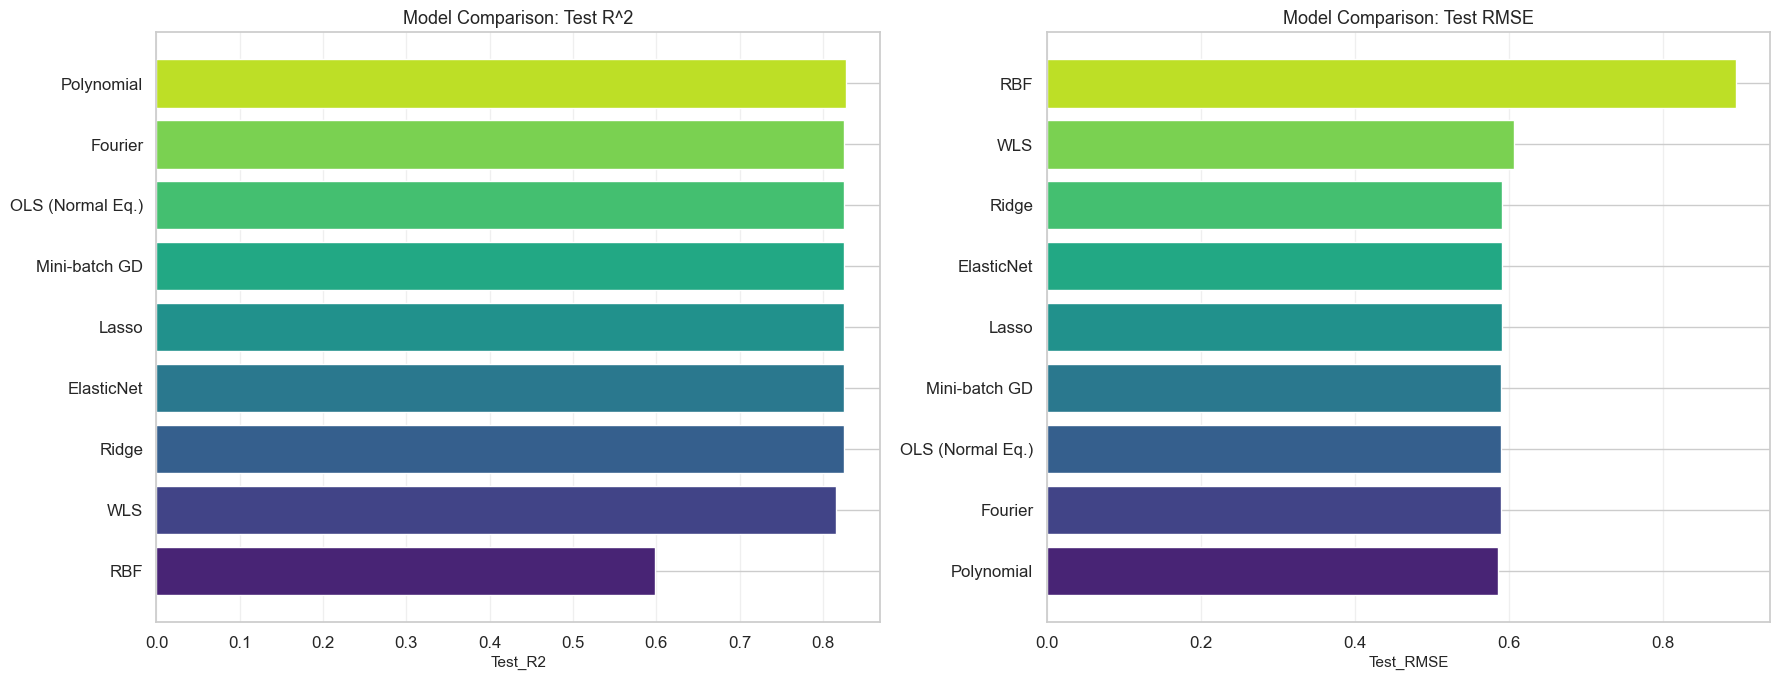

In [16]:
# Visual comparison of all models.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# R^2 comparison
plot_model_comparison(
    results_df, metric="Test_R2",
    title="Model Comparison: Test R^2", ax=axes[0],
)

# RMSE comparison
plot_model_comparison(
    results_df, metric="Test_RMSE",
    title="Model Comparison: Test RMSE", ax=axes[1],
)

plt.tight_layout()
plt.show()

## 6.10. Tóm tắt & Kết luận

Qua quá trình đánh giá đa chiều bao gồm Learning Curves, Residual Analysis, Cross-Validation và kiểm định thống kê, các kết luận chính được rút ra như sau:

1. **Mô hình tối ưu — Polynomial Regression:** Đứng đầu bảng xếp hạng với Test $R^2 = 0.8284$, Test RMSE = 0.5855, và CV $R^2 = 0.8239 \pm 0.0103$. Kiểm định Paired t-test xác nhận Polynomial vượt trội hơn OLS baseline với $p = 7.44 \times 10^{-5}$ ($\Delta R^2 = +0.0058$, 95% CI: $[0.0039, 0.0077]$). Mô hình này đồng thời có $\sigma_{\text{CV}}$ thấp nhất (0.0103), cho thấy tính ổn định cao nhất qua các fold.

2. **Nhóm tuyến tính tương đương thống kê:** OLS, Ridge, Lasso, ElasticNet, Fourier, và Mini-batch GD cho hiệu năng không phân biệt được về mặt thống kê (tất cả $p > 0.23$). Test $R^2$ dao động trong khoảng hẹp $[0.8250, 0.8252]$. Trong nhóm này, regularization ($L_1$/$L_2$) không mang lại cải thiện có ý nghĩa, cho thấy overfitting không phải là vấn đề chính với bộ đặc trưng 49 chiều trên 12,165 mẫu huấn luyện.

3. **WLS — đánh đổi bias-variance:** WLS giảm heteroscedasticity hiệu quả (Val MAE = 0.4115, thấp nhất) nhưng hy sinh $R^2$ tổng thể (Test $R^2 = 0.8148$, kém OLS có ý nghĩa thống kê với $p = 8.44 \times 10^{-7}$). Mô hình này phù hợp khi ưu tiên dự đoán chính xác ở vùng median hơn là tối ưu $R^2$.

4. **RBF Network — không phù hợp:** Kết quả kém nhất toàn diện (Test $R^2 = 0.6001$, thấp hơn OLS 22.5 điểm phần trăm) với $p = 3.20 \times 10^{-10}$. Cấu hình hiện tại của RBF không phù hợp với cấu trúc dữ liệu 49 chiều này.

**Khuyến nghị:** Polynomial Regression được chọn là mô hình tối ưu cho bài toán dự đoán lưu lượng thuê xe. Tuy nhiên, phân tích phần dư cho thấy vẫn tồn tại hiện tượng under-prediction ở vùng giá trị cao và heavy tails trong phân phối phần dư, gợi ý hướng cải thiện tiếp theo có thể bao gồm: (i) bổ sung đặc trưng tương tác bậc cao, (ii) áp dụng hàm mất mát robust (Huber loss), hoặc (iii) sử dụng các mô hình ensemble (Random Forest, Gradient Boosting) để nắm bắt tốt hơn quan hệ phi tuyến phức tạp.